In [1]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")
 
import os
import sys
import time
import logging
from pathlib import Path
 
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA

In [ ]:
# =============================================================================
# USER CONFIGURATION -- edit these to match your environment
# =============================================================================
 
# Path to cloned SpaCross repo (for SpaCross package + Config/DLPFC.yaml)
SPACROSS_ROOT = Path(r"/home/dal875013/work/projects/mocha/methods/spacross/SpaCross")
 
# Path to the folder containing SCE_151*.h5ad files
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/MOB_ST/data")
 
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/mob_spacross")
 
# SpaCross config (the repo's Config/DLPFC.yaml)
CONFIG_PATH = SPACROSS_ROOT / "Config" / "MOB.yaml"
 
# All 12 MOB slice IDs (simple integers 1-12)
ALL_MOB_SAMPLES = [str(i) for i in range(11, 13)]  # "1", "2", ..., "12"
 
# ----- SUBSET SELECTOR -----------------------------------------------------
# Set SAMPLES_TO_RUN to:
#   - None or "all" -> run all 12 slices
#   - A list like ["1", "5", "12"] -> only run those slices
#   - A single string "5" -> run just that one
SAMPLES_TO_RUN = "all" 
 
# Method name (written to the 'method' column in parquet files)
METHOD_NAME = "SpaCross"
 
# Clustering algorithm: "mclust" (needs R+mclust, painful on Windows) or "kmeans"
CLUST_METHOD = "mclust"
 
# Number of runs per slice (>1 enables variance estimation)
NUM_RUNS = 1
 
# MOB has 4 annotated layers: GL / ONL / MCL / GCL
# We cluster into this many groups (matching ground truth).
NUM_CLUSTERS_MOB = 4
 
# Which column in adata.obs holds the ground-truth layer labels.
# For MOB files this is 'z' (same as DLPFC's h5ad format).
GT_LABEL_COL = "z"
 
# Spatial coordinate key in adata.obsm (MOB files use 'S', not 'spatial')
SPATIAL_KEY = "S"
 
 
# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    """Return 'cuda:0' if a CUDA GPU is available, else 'cpu'. Logs details."""
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available -- using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU -- falling back to CPU (slow)")
    return dev
 
 
# =============================================================================
# Logging setup
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w", encoding="utf-8"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")

# =============================================================================
# Helpers
# =============================================================================
def resolve_samples(selector) -> list:
    """Turn SAMPLES_TO_RUN into a concrete list of slice IDs."""
    if selector is None or selector == "all":
        return list(ALL_MOB_SAMPLES)
    if isinstance(selector, str):
        return [selector]
    if isinstance(selector, (list, tuple)):
        return [str(s) for s in selector]
    raise ValueError(f"Unrecognized SAMPLES_TO_RUN value: {selector!r}")

In [3]:
# =============================================================================
# Data loading  (MOB-specific)
# =============================================================================
def load_mob_sample(config: dict, sample_id: str, tools_mod):
    """
    Load and preprocess a single MOB .h5ad file.
 
    Note differences from DLPFC:
      - Filename is SCE_<int>.h5ad (e.g. SCE_1.h5ad), not SCE_151507.h5ad
      - Spot count is ~280 per slice, so very fast
      - Ground truth has 4 classes (GL/ONL/MCL/GCL), not 7
 
    Returns:
        adata       : preprocessed AnnData
        edge_index  : torch sparse tensor (k-NN graph from spatial coords)
    """
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")
 
    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()
 
    # ---- DIAGNOSTIC ----
    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")
 
    # ---- Ground-truth label column ----
    if GT_LABEL_COL not in adata.obs.columns:
        raise KeyError(
            f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
            f"Available: {list(adata.obs.columns)}"
        )
    adata.obs["layer_guess"] = adata.obs[GT_LABEL_COL].astype(object)
    gt_vals = adata.obs["layer_guess"]
    n_labeled = gt_vals.notna().sum()
    uniq_labels = sorted([str(x) for x in gt_vals.dropna().unique()])
    logging.info(
        f"  [DIAG] Using GT column '{GT_LABEL_COL}'  "
        f"(labeled: {n_labeled}/{adata.n_obs}, classes: {uniq_labels})"
    )
 
    # ---- Alias spatial coords ----
    # MOB .h5ad stores coords in obsm['S'] as a pandas DataFrame.
    # SpaCross graph_construction expects obsm['spatial'] as a numpy array.
    if "spatial" not in adata.obsm:
        if SPATIAL_KEY in adata.obsm:
            coords = adata.obsm[SPATIAL_KEY]
            # Convert DataFrame -> numpy, or pass through if already numpy
            adata.obsm["spatial"] = np.asarray(coords)
            logging.info(
                f"  [DIAG] Aliased obsm['{SPATIAL_KEY}'] -> obsm['spatial']"
            )
        else:
            raise KeyError(
                f"No spatial coordinates in {h5ad_path}. "
                f"Available obsm: {list(adata.obsm.keys())}"
            )
    logging.info(
        f"  [DIAG] spatial coords shape: {adata.obsm['spatial'].shape}"
    )
 
    # ---- Build k-NN spatial graph ----
    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)
    logging.info(f"  [DIAG] Built k-NN graph (k={k})")
 
    # ---- Preprocessing ----
    # Keep the raw counts in a layer for HVG selection (seurat_v3 flavor
    # needs raw counts).
    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()
 
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(f"  [DIAG] After gene filter: n_vars={adata.n_vars}")
 
    sc.pp.normalize_total(adata, target_sum=1e6)
    # MOB notebook uses log1p; we keep normalize + HVG to match the SpaCross
    # DLPFC-style pipeline (not the Stereo+Slide combined variant).
    top_g = min(config["data"]["top_genes"], adata.n_vars)
    sc.pp.highly_variable_genes(
        adata, flavor="seurat_v3", layer="count", n_top_genes=top_g,
    )
    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)
    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata.n_vars} (target={top_g})"
    )
 
    # ---- PCA ----
    # MOB is much smaller than DLPFC (~280 spots vs ~4200), so PCA components
    # cannot exceed min(n_spots, n_genes).
    n_pcs = min(200, adata.n_vars, adata.n_obs - 1)
    adata.obsm["X_pca"] = PCA(
        n_components=n_pcs, random_state=42
    ).fit_transform(adata.X)
    logging.info(f"  [DIAG] PCA done: X_pca shape={adata.obsm['X_pca'].shape}")
 
    return adata, edge_index

In [ ]:
# =============================================================================
# Training + metrics for one slice
# =============================================================================
def train_one_slice(
    sample_id: str,
    adata,
    edge_index,
    config: dict,
    device: str,
    tools_mod,
    clust_method: str = "kmeans",
    run_seed: int = 0,
):
    """Train SpaCross on one MOB slice and compute ARI/NMI/ACC/DIS."""
    NUM_CLUSTERS_MOB = 5
    num_clusters = NUM_CLUSTERS_MOB
    logging.info(
        f"  [TRAIN] Starting SpaCross | slice={sample_id} | "
        f"k_clusters={num_clusters} | device={device} | run_seed={run_seed}"
    )
 
    t0 = time.time()
 
    net = tools_mod.SC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )
 
    # Note: SpaCross API intentionally spells it 'trian', not 'train'
    net.trian()
    enc_rep, recon = net.process()
 
    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon
    logging.info(
        f"  [DIAG] Latent shape: {enc_rep.shape}  Recon shape: {recon.shape}"
    )
 
    pred_labels = tools_mod.clustering(
        z=enc_rep, n_clust=num_clusters, num_seed=1, method=clust_method,
    )
    adata.obs[clust_method] = pred_labels
    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )
 
    elapsed = time.time() - t0
 
    # Metrics
    sub_adata = adata[~pd.isnull(adata.obs["layer_guess"])]
    ARI, ACC, DIS = tools_mod.get_metrics(sub_adata, "layer_guess", clust_method)
    from SpaCross.Utils import compute_NMI
    NMI = compute_NMI(sub_adata, "layer_guess", clust_method)
 
    gpu_name = (
        torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
    )
 
    metrics = {
        "method": METHOD_NAME,
        "sample": sample_id,
        "run_seed": run_seed,
        "ARI": float(ARI),
        "ACC": float(ACC),
        "DIS": float(DIS),
        "NMI": float(NMI),
        "running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "clust_method": clust_method,
        "device": device,
        "dataset": "MOB",
    }
    logging.info(
        f"  [METRICS] ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
        f"DIS={DIS:.4f}  time={elapsed:.1f}s  gpu={gpu_name}"
    )
 
    # Per-spot predictions
    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "sample": sample_id,
        "run_seed": run_seed,
        "spot_id": adata.obs_names.astype(str).to_numpy(),
        "true_label": adata.obs["layer_guess"].astype(object).to_numpy(),
        "pred_label": np.asarray(adata.obs[clust_method]).astype(str),
    })
 
    return metrics, pred_df

In [9]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)
 
    logging.info("=" * 72)
    logging.info("SpaCross MOB Benchmarking Framework")
    logging.info("=" * 72)
 
    # --- Register SpaCross package ---
    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(
            f"SPACROSS_ROOT not found: {SPACROSS_ROOT.resolve()}\n"
            f"Clone it with:  git clone https://github.com/wenwenmin/SpaCross.git"
        )
    sys.path.insert(0, str(SPACROSS_ROOT.resolve()))
    import SpaCross as TOOLS  # noqa: N814
 
    device = get_device()
 
    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
    logging.info(f"[PATHS] CONFIG_PATH   = {CONFIG_PATH.resolve()}")
 
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
    logging.info(f"[CONFIG] {config}")
 
    samples = resolve_samples(SAMPLES_TO_RUN)
    logging.info(f"[SAMPLES] Will process {len(samples)} slice(s): {samples}")
    logging.info(
        f"[SETTINGS] clust_method={CLUST_METHOD}  "
        f"num_runs={NUM_RUNS}  num_clusters={NUM_CLUSTERS_MOB}"
    )
 
    all_metrics = []
    all_predictions = []
    failed = []
 
    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] Slice {sample_id}")
        logging.info("-" * 72)
 
        try:
            adata, edge_index = load_mob_sample(config, sample_id, TOOLS)
 
            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")
                adata_run = adata.copy()
 
                metrics, pred_df = train_one_slice(
                    sample_id=sample_id,
                    adata=adata_run,
                    edge_index=edge_index,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )
                all_metrics.append(metrics)
                all_predictions.append(pred_df)
 
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
 
        except Exception as e:
            logging.exception(f"[FAILED] Slice {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})
            continue
 
    # ---- Save ----
    if not all_metrics:
        logging.error("No successful runs -- nothing to save.")
        return
 
    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)
 
    perf_lead = ["method", "sample", "run_seed",
                 "ARI", "NMI", "ACC", "DIS",
                 "running_time_sec", "gpu_model"]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]
    pred_lead = ["method", "sample", "run_seed", "spot_id",
                 "true_label", "pred_label"]
    predictions = predictions[pred_lead]
 
    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"
    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)
 
    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)
    logging.info(
        f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)"
    )
    logging.info(
        f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)"
    )
 
    logging.info("")
    logging.info("Per-sample metrics:")
    logging.info("\n" + performance[
        ["sample", "ARI", "NMI", "ACC", "DIS", "running_time_sec"]
    ].to_string(index=False))
 
    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )
    logging.info(
        f"GPU model(s) used: "
        f"{sorted(performance['gpu_model'].unique().tolist())}"
    )
    logging.info(
        f"Total running time: "
        f"{performance['running_time_sec'].sum():.1f}s"
    )
 
    if failed:
        logging.warning(f"\n{len(failed)} slice(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['sample']}: {f_['error']}")
 
    logging.info("\nBenchmarking complete.")
 
 
if __name__ == "__main__":
    run_benchmark()

2026-04-27 15:38:30,565 [INFO] Log file: /home/dal875013/work/projects/mocha/results/mob_spacross/benchmark.log
2026-04-27 15:38:30,566 [INFO] ========================================================================
2026-04-27 15:38:30,567 [INFO] SpaCross MOB Benchmarking Framework
2026-04-27 15:38:30,569 [INFO] ========================================================================


2026-04-27 15:38:30,575 [INFO] [DEVICE] CUDA available -- using cuda:0
2026-04-27 15:38:30,576 [INFO] [DEVICE] GPU name: NVIDIA A30
2026-04-27 15:38:30,577 [INFO] [DEVICE] GPU memory: 25.22 GB
2026-04-27 15:38:30,583 [INFO] [PATHS] SPACROSS_ROOT = /work/dal875013/projects/mocha/methods/spacross/SpaCross
2026-04-27 15:38:30,585 [INFO] [PATHS] DATA_ROOT     = /groups/qiwei/mocha/QuickSRT/MOB_ST/data
2026-04-27 15:38:30,587 [INFO] [PATHS] OUTPUT_DIR    = /work/dal875013/projects/mocha/results/mob_spacross
2026-04-27 15:38:30,595 [INFO] [PATHS] CONFIG_PATH   = /work/dal875013/projects/mocha/methods/spacross/SpaCross/Config/MOB.yaml
2026-04-27 15:38:30,599 [INFO] [CONFIG] {'data': {'dataset': 'Stereo', 'k_cutoff': 10, 'top_genes': 2000}, 'model': {'dic_hidden': 64, 'feat_hidden1': 64, 'feat_hidden2': 32, 'gcn_hidden': 64, 'latent_dim': 16, 'mask_rate': 0.6, 'momentum_rate': 0.0, 'p_drop': 0.2, 'project_dim': 32, 't': 2}, 'seed': 3407, 'train': {'epochs': 300, 't_step': 50, 'topk_neighs': 10

Epoch 299 total loss=1.219 recon loss=1.161 mean loss=0.383 tri loss=1.397: 100%|██████████| 300/300 [00:03<00:00, 90.02it/s]

2026-04-27 15:38:34,236 [INFO]   [DIAG] Latent shape: (262, 16)  Recon shape: (262, 200)


[DEBUG mclust] emb shape = (262, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-27 15:38:34,484 [INFO]   [DIAG] Cluster sizes: {'1': 60, '3': 60, '4': 57, '5': 54, '2': 31}
2026-04-27 15:38:34,504 [INFO]   [METRICS] ARI=0.0205  NMI=0.0435  ACC=0.0435  DIS=0.0967  time=3.6s  gpu=NVIDIA A30
2026-04-27 15:38:34,506 [INFO] 
2026-04-27 15:38:34,507 [INFO] ------------------------------------------------------------------------
2026-04-27 15:38:34,508 [INFO] [2/2] Slice 12
2026-04-27 15:38:34,508 [INFO] ------------------------------------------------------------------------
2026-04-27 15:38:34,509 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/MOB_ST/data/SCE_12.h5ad
2026-04-27 15:38:34,540 [INFO]   [DIAG] Loaded AnnData: n_obs=282, n_vars=16034
2026-04-27 15:38:34,541 [INFO]   [DIAG] obs columns: ['z']
2026-04-27 15:38:34,542 [INFO]   [DIAG] obsm keys  : ['S']
2026-04-27 15:38:34,543 [INFO]   [DIAG] Using GT co

Epoch 299 total loss=1.228 recon loss=1.176 mean loss=0.382 tri loss=1.404: 100%|██████████| 300/300 [00:03<00:00, 92.82it/s]

2026-04-27 15:38:38,022 [INFO]   [DIAG] Latent shape: (282, 16)  Recon shape: (282, 200)


[DEBUG mclust] emb shape = (282, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-27 15:38:38,324 [INFO]   [DIAG] Cluster sizes: {'1': 94, '3': 65, '5': 61, '2': 34, '4': 28}
2026-04-27 15:38:38,347 [INFO]   [METRICS] ARI=0.0734  NMI=0.1175  ACC=0.1177  DIS=0.1023  time=3.6s  gpu=NVIDIA A30
2026-04-27 15:38:38,389 [INFO] 
2026-04-27 15:38:38,392 [INFO] ========================================================================
2026-04-27 15:38:38,393 [INFO] SAVED
2026-04-27 15:38:38,394 [INFO] ========================================================================
2026-04-27 15:38:38,394 [INFO]   predictions.parquet -> /home/dal875013/work/projects/mocha/results/mob_spacross/predictions.parquet  (544 rows)
2026-04-27 15:38:38,395 [INFO]   performance.parquet -> /home/dal875013/work/projects/mocha/results/mob_spacross/performance.parquet  (2 rows)
2026-04-27 15:38:38,395 [INFO] 
2026-04-27 15:38:38,396 [INFO] Per-samp

# prediction results visulization

SAMPLE_ID = 12
n spots in adata      : 282
n predictions matched : 282


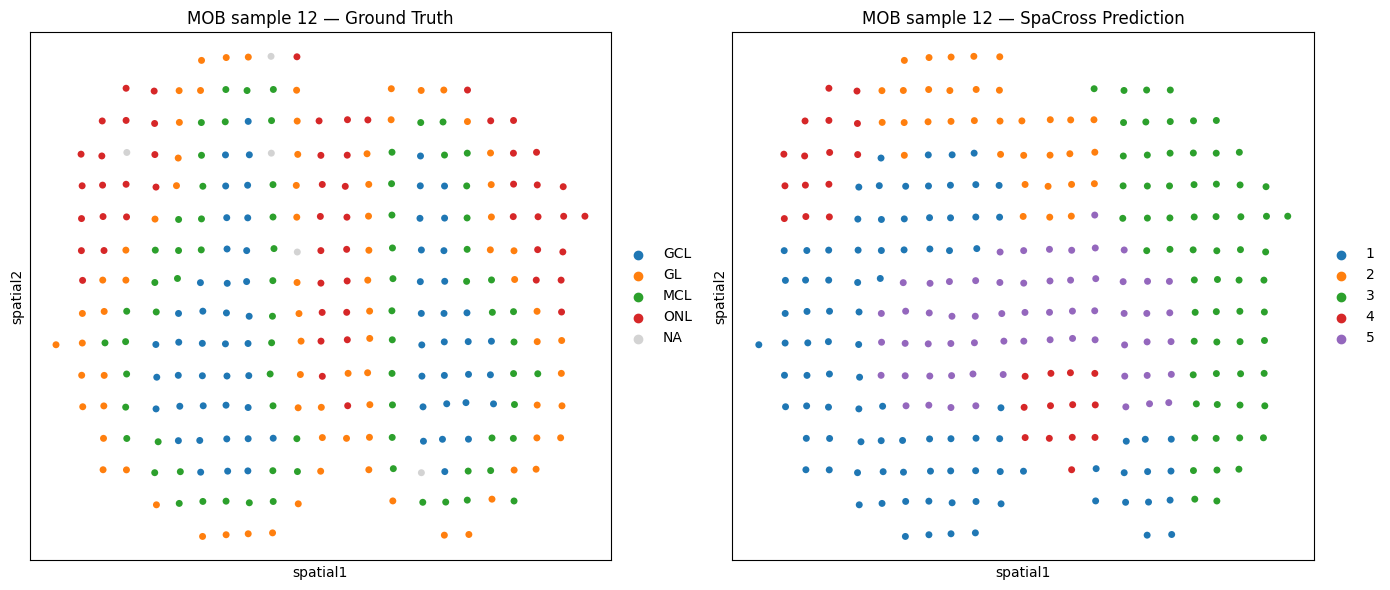

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/MOB_ST/data")
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/mob_spacross")

# "11" or "12"
SAMPLE_ID = "12"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

predictions["sample"] = predictions["sample"].astype(str)
pred_slice = predictions[predictions["sample"] == str(SAMPLE_ID)].copy()

if pred_slice.empty:
    raise ValueError(f"No predictions found for sample {SAMPLE_ID}")

pred_slice = pred_slice.set_index("spot_id")

adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")
adata.var_names_make_unique()

if "spatial" not in adata.obsm:
    if "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
    else:
        raise KeyError(f"No spatial coordinates found. obsm keys = {list(adata.obsm.keys())}")

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

print(f"SAMPLE_ID = {SAMPLE_ID}")
print(f"n spots in adata      : {adata.n_obs}")
print(f"n predictions matched : {pred_slice.index.isin(adata.obs_names).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="true_label",
    ax=axes[0],
    show=False,
    title=f"MOB sample {SAMPLE_ID} — Ground Truth",
    s=100,
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="pred_label",
    ax=axes[1],
    show=False,
    title=f"MOB sample {SAMPLE_ID} — SpaCross Prediction",
    s=100,
)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# Running results summary

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/mob_spacross")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)

# sample order to get all output
performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "sample", "run_seed", "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "clust_method", "gpu_model"
]

display_cols = [c for c in display_cols if c in performance.columns]

print("===== All SpaCross results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary = performance[["ARI", "NMI", "ACC", "DIS", "running_time_sec"]].describe()
display(summary)

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All SpaCross results =====


,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,clust_method,gpu_model
0,11,0,0.015536,0.038142,0.038296,0.092895,4,262,260,5.33,mclust,NVIDIA A30
1,12,0,0.043331,0.098899,0.099175,0.107498,4,282,277,3.75,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,2.000000,2.000000,2.000000,2.000000,2.000000
mean,0.029434,0.068521,0.068735,0.100196,4.540000
std,0.019654,0.042962,0.043047,0.010326,1.117229
min,0.015536,0.038142,0.038296,0.092895,3.750000
25%,0.022485,0.053332,0.053516,0.096546,4.145000
50%,0.029434,0.068521,0.068735,0.100196,4.540000
75%,0.036382,0.083710,0.083955,0.103847,4.935000
max,0.043331,0.098899,0.099175,0.107498,5.330000



===== Mean metrics =====
Mean ARI: 0.0294
Mean NMI: 0.0685
Mean ACC: 0.0687
Mean DIS: 0.1002

===== Best / worst ARI =====
Best ARI : 12  ARI=0.0433
Worst ARI: 11  ARI=0.0155


In [ ]:
# actual layer in ground truth checking

import scanpy as sc
import pandas as pd
from pathlib import Path

DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/MOB_ST/data")

ALL_MOB_SAMPLES = [str(i) for i in range(1, 13)]

results = []

for sample_id in ALL_MOB_SAMPLES:
    path = DATA_ROOT / f"SCE_{sample_id}.h5ad"

    if not path.exists():
        print(f"[MISSING] {sample_id}: {path}")
        continue

    adata = sc.read_h5ad(path)

    if "z" not in adata.obs:
        print(f"[NO LABEL] {sample_id}; obs columns = {list(adata.obs.columns)}")
        continue

    labels_all = adata.obs["z"]

    # remove NaN labels
    labels = labels_all.dropna()

    unique_labels = sorted(labels.unique())
    n_classes = len(unique_labels)

    results.append({
        "sample": sample_id,
        "n_classes": n_classes,
        "labels": unique_labels,
        "n_spots": adata.n_obs,
        "n_labeled": len(labels),
        "n_NA": int(labels_all.isna().sum()),
    })

df = pd.DataFrame(results).sort_values(["n_classes", "sample"])

print("===== MOB_ST: Per-sample class counts =====")
display(df)

print("\n===== Summary =====")
print(df["n_classes"].value_counts().sort_index())

print("\n===== Samples with only 1 class =====")
print(df[df["n_classes"] == 1]["sample"].tolist())

print("\n===== Suggested dictionary: sample -> n_classes =====")
cluster_dict = dict(zip(df["sample"], df["n_classes"]))
print(cluster_dict)

[NO LABEL] 1; obs columns = []
[NO LABEL] 2; obs columns = []
[NO LABEL] 3; obs columns = []
[NO LABEL] 4; obs columns = []
[NO LABEL] 5; obs columns = []
[NO LABEL] 6; obs columns = []
[NO LABEL] 7; obs columns = []
[NO LABEL] 8; obs columns = []
[NO LABEL] 9; obs columns = []
[NO LABEL] 10; obs columns = []
===== MOB_ST: Per-sample class counts =====


,sample,n_classes,labels,n_spots,n_labeled,n_NA
1,12,4,"[GCL, GL, MCL, ONL]",282,277,5
0,11,5,"[GCL, GL, MCL, ONL, OPL]",262,260,2



===== Summary =====
n_classes
4    1
5    1
Name: count, dtype: int64

===== Samples with only 1 class =====
[]

===== Suggested dictionary: sample -> n_classes =====
{'12': 4, '11': 5}
